# CakapKarier AI - Career Match Experiment

Notebook ini menjadi ringkasan kerja AI Engineer untuk capstone: assessment dataset scraping Glints, preprocessing, training TensorFlow Functional API, custom component, evaluasi, export model, inference, API contract, dan TensorBoard.

Logic utama tetap disimpan di module Python agar reproducible dan mudah dipakai oleh backend. Notebook ini berperan sebagai laporan eksperimen dan demo.

## 1. Setup Path dan Konfigurasi

Cell ini dibuat robust agar notebook bisa dijalankan dari folder repo root, folder `AIEngine`, atau langsung dari folder `notebooks`.

In [1]:
from pathlib import Path
import importlib
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt


def find_ai_engine_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if path.name == 'AIEngine' and (path / 'pipelines').exists():
            return path
        candidate = path / 'AIEngine'
        if (candidate / 'pipelines').exists():
            return candidate
    raise RuntimeError('Folder AIEngine tidak ditemukan dari current working directory.')


AIENGINE_ROOT = find_ai_engine_root(Path.cwd())
REPO_ROOT = AIENGINE_ROOT.parent
SERVICE_SRC = AIENGINE_ROOT / 'services' / 'career-match' / 'src'

for path in [AIENGINE_ROOT, SERVICE_SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

importlib.invalidate_caches()

DS_CLEAN_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'all_data_clean.csv'
DS_DICTIONARY_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'Data_Dictionary.xlsx'
RAW_PATHS = [DS_CLEAN_PATH] if DS_CLEAN_PATH.exists() else []
PROCESSED_DIR = AIENGINE_ROOT / 'data' / 'processed' / 'career-match-v1'
MODEL_DIR = AIENGINE_ROOT / 'models' / 'registry' / 'career-match' / 'v1'

# Ubah menjadi True jika ingin menjalankan ulang dari awal.
RUN_PREPROCESSING = False
RUN_TRAINING = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

def plot_barh(series, title, xlabel='Count', color='#2563eb'):
    ax = series.sort_values().plot(kind='barh', color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

print('AIENGINE_ROOT =', AIENGINE_ROOT)
print('RAW_PATHS =', RAW_PATHS)
print('MODEL_DIR exists =', MODEL_DIR.exists())


AIENGINE_ROOT = C:\DBS Foundation\CakapKarier AI\AIEngine
RAW_PATHS = [WindowsPath('C:/DBS Foundation/CakapKarier AI/AIEngine/data/raw/all_data_clean.csv')]
MODEL_DIR exists = True


## 2. Business Objective

Project CakapKarier AI membutuhkan model untuk membantu pengguna memahami kesiapan kerja, role yang paling relevan, skill gap, dan rekomendasi pengembangan skill. Karena dataset yang tersedia berisi lowongan kerja, model dibangun sebagai career matching model: kandidat dibandingkan terhadap katalog lowongan, lalu sistem mengembalikan readiness score dan rekomendasi role terbaik.

Checklist yang dipenuhi:

- TensorFlow Functional API
- Custom Layer: `CosineSimilarityLayer`, `AbsoluteDifferenceLayer`
- Custom Loss Function: `CareerMatchLoss`
- Custom Callback: `QualityThresholdCallback`
- Custom training loop dengan `tf.GradientTape`
- Export `.keras` dan SavedModel
- Inference code dan FastAPI service
- TensorBoard log
- Optional GenAI summary fallback

## 3. Raw Dataset Assessment

In [2]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)
raw_df = preprocess_module.load_raw_sources(RAW_PATHS)

raw_summary = {
    'rows': len(raw_df),
    'columns': list(raw_df.columns),
    'source_distribution': raw_df['source'].value_counts().to_dict() if 'source' in raw_df.columns else {},
    'missing_values': raw_df.isna().sum().to_dict(),
    'duplicate_job_detail': int(raw_df.duplicated('job_detail').sum()) if 'job_detail' in raw_df else None,
    'unique_job_titles': int(raw_df['job_title'].nunique()) if 'job_title' in raw_df else None,
}
raw_summary


{'rows': 2209,
 'columns': ['source',
  'source_sheet',
  'source_row_id',
  'job_title',
  'company',
  'location',
  'job_detail',
  'description',
  'requirements',
  'skills_text',
  'skills_clean_text',
  'job_benefits'],
 'source_distribution': {'glints': 1980, 'linkedin': 229},
 'missing_values': {'source': 0,
  'source_sheet': 0,
  'source_row_id': 0,
  'job_title': 0,
  'company': 0,
  'location': 0,
  'job_detail': 0,
  'description': 0,
  'requirements': 0,
  'skills_text': 0,
  'skills_clean_text': 0,
  'job_benefits': 0},
 'duplicate_job_detail': 228,
 'unique_job_titles': 1331}

In [3]:
if DS_DICTIONARY_PATH.exists():
    ds_dictionary = pd.read_excel(DS_DICTIONARY_PATH)
    display(ds_dictionary)
else:
    print('Data dictionary DS belum tersedia di AIEngine/data/raw/Data_Dictionary.xlsx')


,No,Column,Data Type,Deskripsi
0,1,web_scraper_order,Object/String,ID urutan hasil scraping untuk setiap data low...
1,2,web_scraper_start_url,Object/String,URL awal halaman scraping yang digunakan untuk...
2,3,job_title,Object/String,Nama posisi pekerjaan yang ditawarkan.
3,4,company,Object/String,Nama perusahaan yang membuka lowongan kerja.
4,5,location,Object/String,Lokasi perusahaan atau lokasi pekerjaan tersedia.
5,6,job_detail,Object/String,URL detail lowongan pekerjaan yang mengarah ke...
6,7,description,Object/String,"Deskripsi umum mengenai pekerjaan, tanggung ja..."
7,8,requirements,Object/String,Kualifikasi atau syarat yang dibutuhkan (Pendi...
8,9,skills,Object/String,Daftar skill atau kemampuan yang dibutuhkan da...
9,10,job_benefits,Object/String,Informasi benefit atau keuntungan yang diberik...


,source,source_sheet,job_title,company,location,requirements,skills_text
0,glints,,Technical Support Intern,Wirakom Sistem,"Tangerang Selatan, Banten",Job RequirementsOn-site1 - 3 years of experien...,SkillsTechnical SupportIT SupportNetwork Troub...
1,glints,,Mandarin Secretary,Pt. Sentum Teknologi Indonesia,"Jakarta Utara, Dki Jakarta",Job RequirementsOn-site1 - 3 years of experien...,SkillsCommunication SkillsMicrosoft OfficeAdmi...
2,glints,,Sales Manager,Pt United Teknologi Integrasi,"Jakarta Pusat, Dki Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsGive it a try! - 1 of 12 skills match yo...
3,glints,,Project Manager,Bisnis Adviz Solusi,"Jakarta Pusat, Dki Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsProject ManagementRisk ManagementTeam Ma...
4,glints,,"Software Developer (Java Springboot, Golang, R...",Pt Sigma Global Teknologi,"Jakarta Selatan, Dki Jakarta",Job RequirementsOn-site5 - 10 years of experie...,SkillsSpringbootCore JavaSoftware DevelopmentJ...


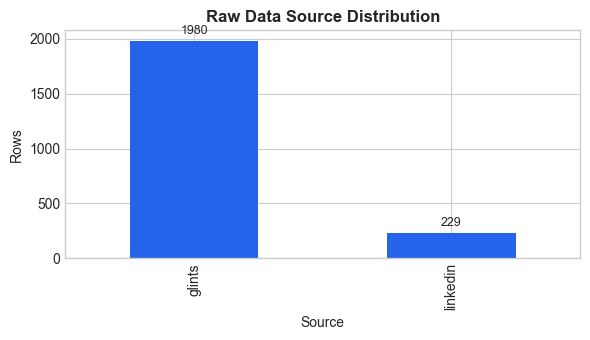

,count
job_title,
It Support,42
It Project Manager,34
System Analyst,30
It Business Analyst,29
Data Engineer,25
Technical Writer,17
It Sales Executive,17
Staff It,17
Software Developer,16


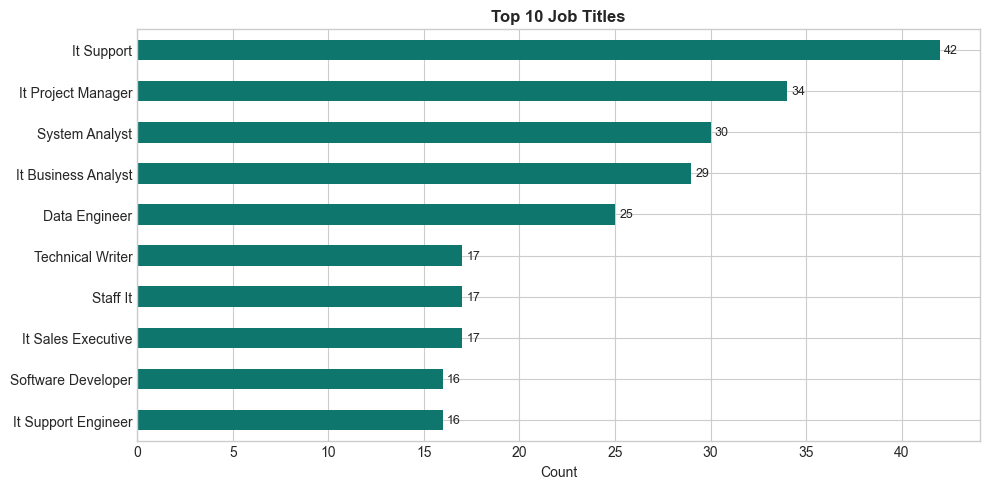

,count
location,
"Jakarta Selatan, Dki Jakarta",572
"Jakarta Pusat, Dki Jakarta",170
"Jakarta Barat, Dki Jakarta",137
"Surabaya, Jawa Timur",132
"Jakarta Utara, Dki Jakarta",102
"Tangerang, Banten",77
"Tangerang Selatan, Banten",67
"Bandung, Jawa Barat",61
"Jakarta Timur, Dki Jakarta",59


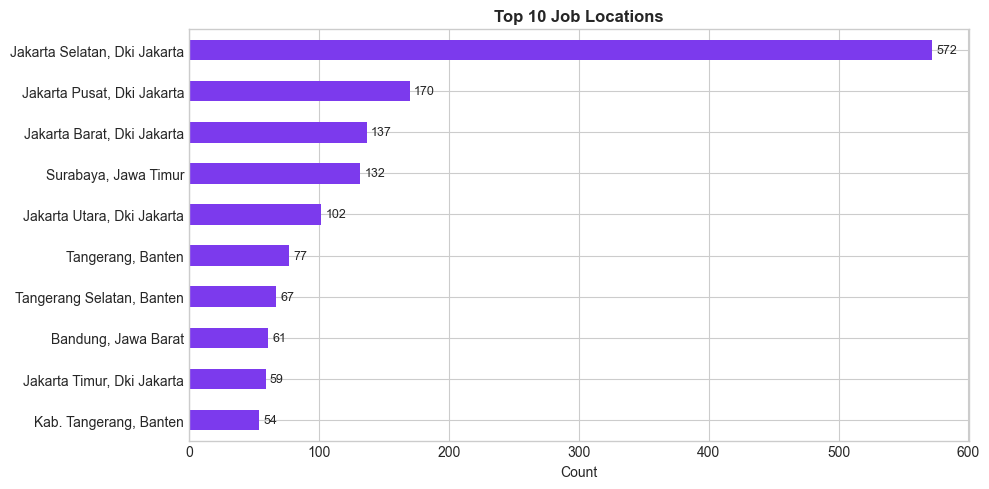

Tidak ada missing value pada dataset raw.


In [4]:
preview_cols = [
    col for col in [
        'source',
        'source_sheet',
        'job_title',
        'company',
        'location',
        'requirements',
        'skills_text',
    ]
    if col in raw_df.columns
]
display(raw_df[preview_cols].head(5))

fig, ax = plt.subplots(figsize=(6, 3.5))
raw_df['source'].value_counts().plot(kind='bar', ax=ax, color='#2563eb')
ax.set_title('Raw Data Source Distribution')
ax.set_xlabel('Source')
ax.set_ylabel('Rows')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

top_titles = raw_df['job_title'].value_counts().head(10)
top_locations = raw_df['location'].value_counts().head(10)
missing_values = raw_df.isna().sum().sort_values(ascending=False)

display(top_titles.rename('count').to_frame())
plot_barh(top_titles, 'Top 10 Job Titles', color='#0f766e')

display(top_locations.rename('count').to_frame())
plot_barh(top_locations, 'Top 10 Job Locations', color='#7c3aed')

non_zero_missing = missing_values[missing_values > 0]
if len(non_zero_missing):
    display(non_zero_missing.rename('missing_count').to_frame())
    plot_barh(non_zero_missing, 'Missing Values by Column', color='#dc2626')
else:
    print('Tidak ada missing value pada dataset raw.')


,description_words,requirements_words,skills_chars
count,2209.00,2209.00,2209.00
mean,152.42,8.66,119.12
std,130.29,3.21,85.47
min,1.00,0.00,0.00
25%,71.00,9.00,63.00
50%,130.00,9.00,100.00
75%,208.00,11.00,146.00
max,1106.00,13.00,893.00


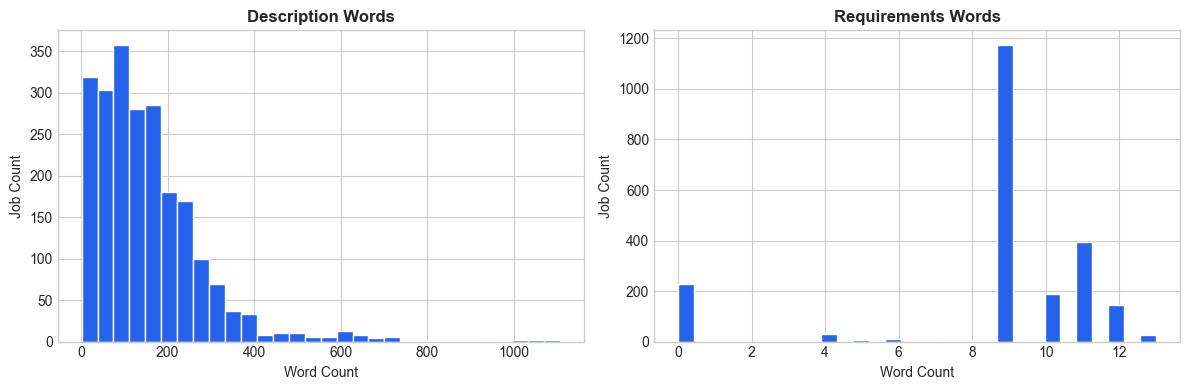

In [5]:
skills_column = 'skills_text' if 'skills_text' in raw_df.columns else None
text_length_df = pd.DataFrame({
    'description_words': raw_df['description'].fillna('').astype(str).str.split().str.len(),
    'requirements_words': raw_df['requirements'].fillna('').astype(str).str.split().str.len(),
    'skills_chars': raw_df[skills_column].fillna('').astype(str).str.len() if skills_column else 0,
})

display(text_length_df.describe().round(2))

axes = text_length_df[['description_words', 'requirements_words']].hist(
    bins=30,
    figsize=(12, 4),
    color='#2563eb',
    edgecolor='white',
)
for ax in axes.flatten():
    ax.set_title(ax.get_title().replace('_', ' ').title())
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Job Count')
plt.tight_layout()
plt.show()


## 4. Preprocessing dan Weak Supervision

Dataset scraping tidak memiliki label kandidat cocok/tidak cocok. Untuk MVP, label dibuat dengan weak supervision:

- Positive pair: kandidat sintetis memenuhi skill, pengalaman, dan pendidikan lowongan.
- Negative pair: kandidat berasal dari role family berbeda atau sengaja dibuat underqualified.

Strategi ini cukup untuk MVP career matching, tetapi versi production sebaiknya dilatih ulang memakai data kandidat nyata dan feedback user.

In [6]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)

if RUN_PREPROCESSING or not (PROCESSED_DIR / 'metadata.json').exists():
    preprocess_metadata = preprocess_module.run(
        raw_paths=RAW_PATHS,
        output_dir=PROCESSED_DIR,
        seed=42,
        negatives_per_job=2,
    )
else:
    preprocess_metadata = json.loads((PROCESSED_DIR / 'metadata.json').read_text(encoding='utf-8'))

preprocess_metadata


{'business_questions': ['Role pekerjaan IT apa yang paling sering muncul dari sumber Glints dan LinkedIn?',
  'Skill apa yang paling banyak diminta oleh pasar kerja?',
  'Bagaimana distribusi pengalaman minimum, work mode, dan lokasi lowongan?',
  'Seberapa siap profil kandidat terhadap lowongan berdasarkan skill, pengalaman, dan sertifikasi?'],
 'raw_sources': ['C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\data\\raw\\all_data_clean.csv'],
 'source_distribution': {'glints': 1980, 'linkedin': 229},
 'source_rows': 2209,
 'unique_job_titles': 1330,
 'pair_counts': {'train': 4635, 'val': 996, 'test': 996},
 'role_family_distribution': {'it-support-network': 499,
  'software-engineering': 365,
  'other-it': 333,
  'qa-security': 310,
  'data-ai': 258,
  'sales-account': 223,
  'product-project-business': 101,
  'admin-operations': 90,
  'design-content': 30},
 'work_mode_distribution': {'unknown': 1958,
  'onsite': 122,
  'remote': 96,
  'hybrid': 33},
 'top_locations': {'Jakarta Selatan,

,split,rows
0,jobs,2209
1,train_pairs,4635
2,val_pairs,996
3,test_pairs,996


,count
role_family,
it-support-network,499
software-engineering,365
other-it,333
qa-security,310
data-ai,258
sales-account,223
product-project-business,101
admin-operations,90
design-content,30


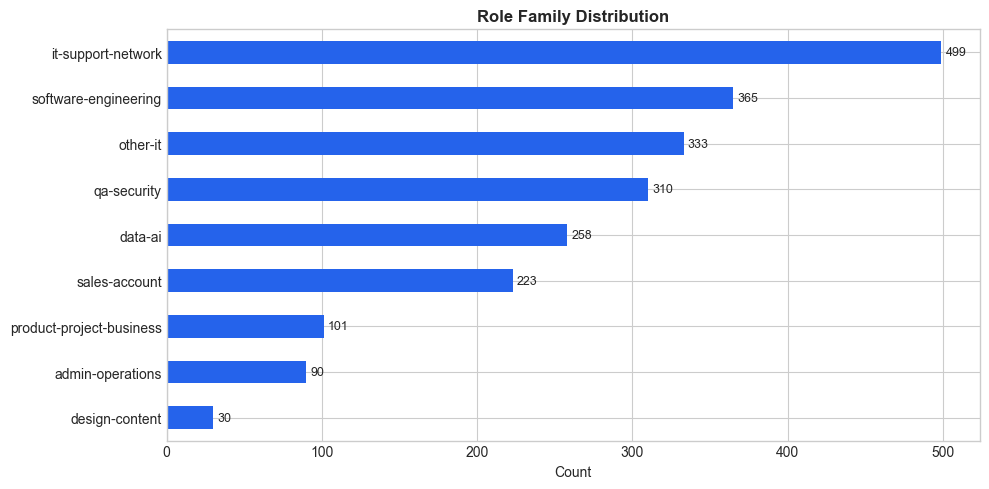

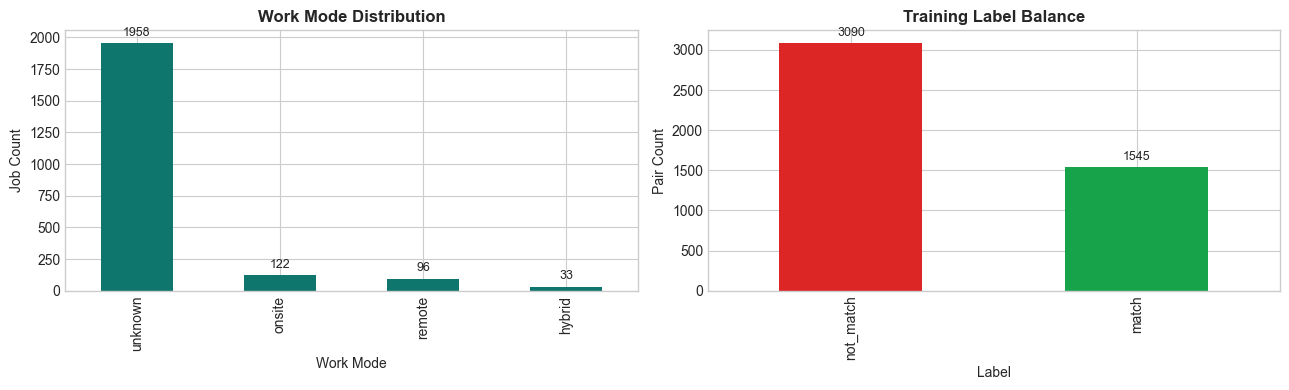

,pair_type,label,count
0,positive_market_fit,1.0,1545
1,negative_underqualified,0.0,1545
2,negative_cross_role,0.0,1545


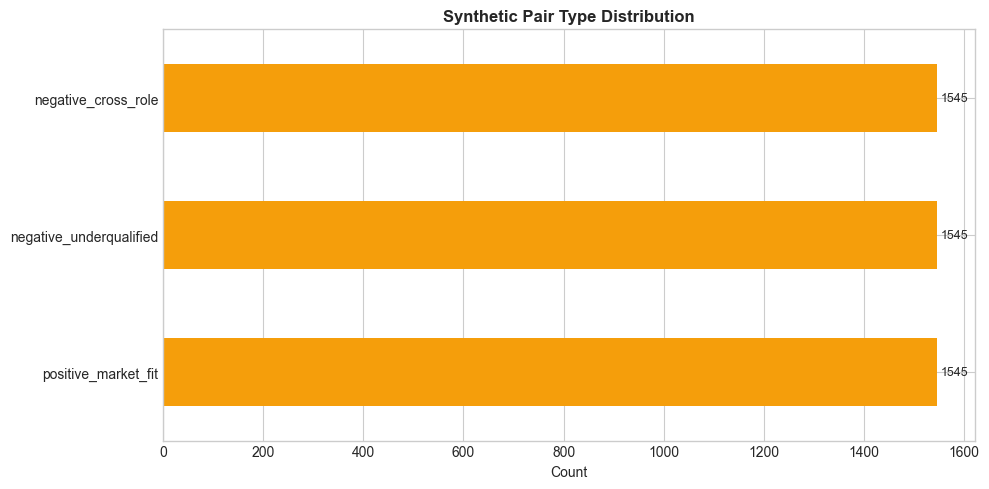

In [7]:
jobs_df = pd.read_csv(PROCESSED_DIR / 'jobs_processed.csv')
train_pairs = pd.read_csv(PROCESSED_DIR / 'train_pairs.csv')
val_pairs = pd.read_csv(PROCESSED_DIR / 'val_pairs.csv')
test_pairs = pd.read_csv(PROCESSED_DIR / 'test_pairs.csv')

processed_summary = pd.DataFrame(
    [
        {'split': 'jobs', 'rows': len(jobs_df)},
        {'split': 'train_pairs', 'rows': len(train_pairs)},
        {'split': 'val_pairs', 'rows': len(val_pairs)},
        {'split': 'test_pairs', 'rows': len(test_pairs)},
    ]
)
display(processed_summary)

role_counts = jobs_df['role_family'].value_counts()
work_mode_counts = jobs_df['work_mode'].value_counts()
pair_type_counts = train_pairs['pair_type'].value_counts()
label_counts = train_pairs['label'].map({0.0: 'not_match', 1.0: 'match'}).value_counts()

display(role_counts.rename('count').to_frame())
plot_barh(role_counts, 'Role Family Distribution', color='#2563eb')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
work_mode_counts.plot(kind='bar', ax=axes[0], color='#0f766e')
axes[0].set_title('Work Mode Distribution')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Job Count')
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

label_counts.plot(kind='bar', ax=axes[1], color=['#dc2626', '#16a34a'])
axes[1].set_title('Training Label Balance')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Pair Count')
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

display(train_pairs[['pair_type', 'label']].value_counts().rename('count').reset_index())
plot_barh(pair_type_counts, 'Synthetic Pair Type Distribution', color='#f59e0b')

,count
communication,469
sql,376
it support,363
python,334
testing,288
technical support,284
troubleshooting,272
cloud,268
network troubleshooting,254
communication skills,250


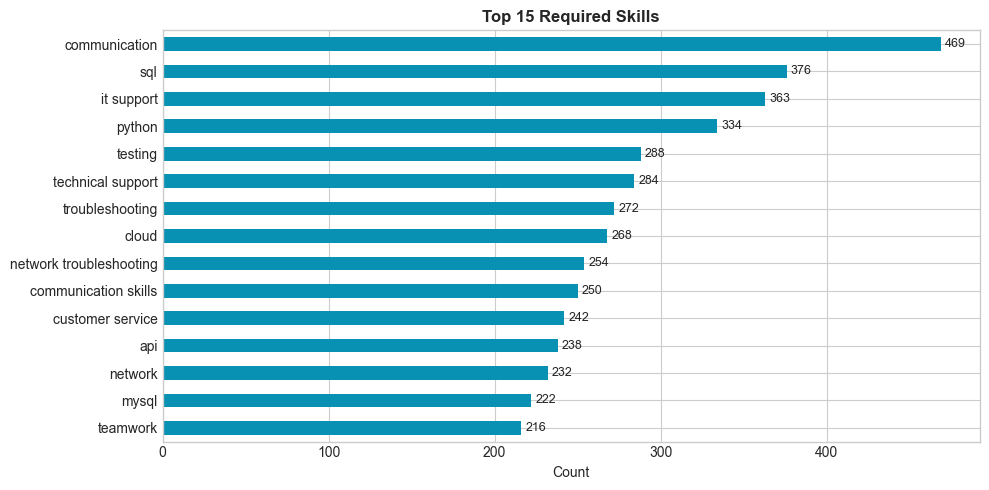

In [8]:
from collections import Counter

skill_counter = Counter()
for value in jobs_df['skills']:
    try:
        skills = json.loads(value) if isinstance(value, str) else value
    except json.JSONDecodeError:
        skills = []
    skill_counter.update(skills)

top_skills = pd.Series(dict(skill_counter.most_common(15)))
display(top_skills.rename('count').to_frame())
plot_barh(top_skills, 'Top 15 Required Skills', color='#0891b2')

## 5. Model Architecture

Model memakai dual text encoder untuk membandingkan `candidate_text` dan `job_text`, lalu digabung dengan fitur numerik readiness. Output akhir adalah sigmoid `match_score` 0 sampai 1.

In [9]:
model_metadata_path = MODEL_DIR / 'metadata.json'
if model_metadata_path.exists():
    model_metadata = json.loads(model_metadata_path.read_text(encoding='utf-8'))
else:
    model_metadata = {
        'status': 'Model belum ditraining. Jalankan cell training dengan RUN_TRAINING=True.'
    }

model_metadata

{'model_name': 'cakapkarier_career_matcher',
 'version': 'v1',
 'framework': 'TensorFlow/Keras',
 'architecture': 'Functional API dual text encoder plus numeric readiness features',
 'custom_components': ['CosineSimilarityLayer',
  'AbsoluteDifferenceLayer',
  'CareerMatchLoss',
  'QualityThresholdCallback',
  'tf.GradientTape custom training loop'],
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'model_path': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\career_match_model.keras',
 'saved_model_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\saved_model',
 'tensorboard_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\tensorboard',
 'evaluation_artifacts': {'classification_report_csv': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\r

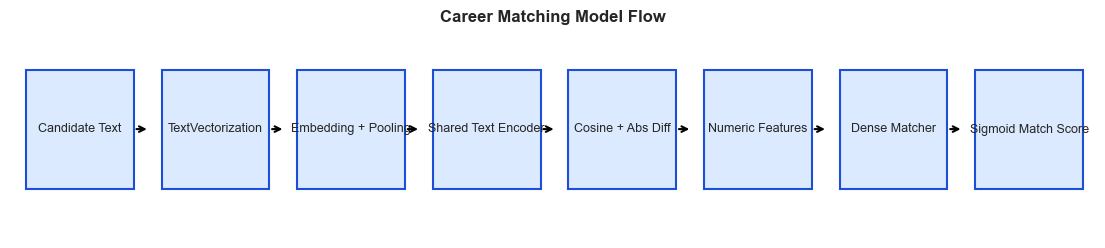

In [10]:
architecture_steps = [
    'Candidate Text',
    'TextVectorization',
    'Embedding + Pooling',
    'Shared Text Encoder',
    'Cosine + Abs Diff',
    'Numeric Features',
    'Dense Matcher',
    'Sigmoid Match Score',
]

fig, ax = plt.subplots(figsize=(14, 2.7))
ax.axis('off')
for idx, label in enumerate(architecture_steps):
    x = idx * 1.7
    box = plt.Rectangle((x, 0.55), 1.35, 0.6, color='#dbeafe', ec='#1d4ed8', lw=1.5)
    ax.add_patch(box)
    ax.text(x + 0.675, 0.85, label, ha='center', va='center', fontsize=9, wrap=True)
    if idx < len(architecture_steps) - 1:
        ax.annotate('', xy=(x + 1.55, 0.85), xytext=(x + 1.35, 0.85), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.set_xlim(-0.2, len(architecture_steps) * 1.7 - 0.2)
ax.set_ylim(0.3, 1.35)
ax.set_title('Career Matching Model Flow')
plt.show()

In [11]:

import tensorflow as tf

importlib.invalidate_caches()
modeling_module = importlib.import_module('career_match.modeling')
modeling_module = importlib.reload(modeling_module)
custom_objects = {
    'CosineSimilarityLayer': modeling_module.CosineSimilarityLayer,
    'AbsoluteDifferenceLayer': modeling_module.AbsoluteDifferenceLayer,
}

model = tf.keras.models.load_model(
    MODEL_DIR / 'career_match_model.keras',
    custom_objects=custom_objects,
    compile=False,
)

# Tabel arsitektur seperti contoh model.summary() Keras.
model.summary(line_length=120, expand_nested=True)

model_io = pd.DataFrame(
    [
        {
            'kind': 'input',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.inputs
    ]
    + [
        {
            'kind': 'output',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.outputs
    ]
)
display(model_io)


Model: "cakapkarier_career_matcher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ candidate_text (InputLayer)       │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ job_text (InputLayer)             │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ shared_text_encoder (Functional)  │ (None, 64)                   │           788,864 │ candidate_text[0][0],     
│                                   │                              │                   │ job_text[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text (InputLayer)            │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ career_text_vectorizer       │ (None, 160)                  │                 0 │ -                         
│ (TextVectorization)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ token_embedding (Embedding)  │ (None, 160, 96)              │           768,000 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ masked_average_pooling       │ (None, 96)                   │                 0 │ -                         
│ (GlobalAveragePooling1D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_layer_norm              │ (None, 96)                   │               192 │ -                         
│ (LayerNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dense_1 (Dense)         │ (None, 128)                  │            12,416 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dropout (Dropout)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_embedding (Dense)       │ (None, 64)                   │             8,256 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_abs_diff                │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│ (AbsoluteDifferenceLayer)         │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_product (Multiply)      │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│                                   │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼───────────────────

 Total params: 844,865 (3.22 MB)

 Trainable params: 844,545 (3.22 MB)

 Non-trainable params: 320 (1.25 KB)

,kind,name,shape,dtype
0,input,candidate_text,"(None,)",string
1,input,job_text,"(None,)",string
2,input,numeric_features,"(None, 7)",float32
3,output,keras_tensor_49,"(None, 1)",float32


## 6. Training, Evaluation, dan Export

Default notebook tidak menjalankan ulang training jika artefak model sudah tersedia. Untuk retraining, ubah `RUN_TRAINING=True` pada cell setup.

In [12]:

from argparse import Namespace

importlib.invalidate_caches()
train_module = importlib.import_module('pipelines.train_model')
train_module = importlib.reload(train_module)

if RUN_TRAINING or not (MODEL_DIR / 'career_match_model.keras').exists():
    train_args = Namespace(
        processed_dir=PROCESSED_DIR,
        model_dir=MODEL_DIR,
        epochs=20,
        min_epochs=5,
        batch_size=64,
        learning_rate=0.0015,
        max_tokens=8000,
        sequence_length=160,
        embedding_dim=96,
        dropout=0.18,
        seed=42,
        min_accuracy=0.85,
        max_mae=0.02,
        skip_threshold_check=False,
    )
    training_metadata = train_module.run_training(train_args)
else:
    training_metadata = json.loads((MODEL_DIR / 'metadata.json').read_text(encoding='utf-8'))
    print('Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.')
    print('Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.')

training_metadata['metrics']


Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.
Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.


{'train': {'loss': 0.00410580774769187,
  'binary_accuracy': 0.9971952438354492,
  'mae': 0.013333464972674847},
 'validation': {'loss': 0.002706635743379593,
  'binary_accuracy': 0.9969879388809204,
  'mae': 0.012775727547705173},
 'test': {'loss': 0.00378962024115026,
  'binary_accuracy': 0.9989959597587585,
  'mae': 0.01200424786657095},
 'thresholds': {'min_accuracy': 0.85, 'max_mae': 0.02},
 'threshold_callback_reached_epoch': 6,
 'training_time': {'epochs_ran': 6,
  'total_epoch_seconds': 58.02,
  'mean_epoch_seconds': 9.67,
  'last_epoch_seconds': 10.505}}

In [13]:
metrics = json.loads((MODEL_DIR / 'metrics.json').read_text(encoding='utf-8'))
metrics_table = pd.DataFrame(
    [
        {'split': split, **metrics[split]}
        for split in ['train', 'validation', 'test']
    ]
)
display(metrics_table)

test_accuracy = metrics['test']['binary_accuracy']
test_mae = metrics['test']['mae']
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print('Target accuracy >= 0.85:', test_accuracy >= 0.85)
print('Target MAE <= 0.02:', test_mae <= 0.02)

,split,loss,binary_accuracy,mae
0,train,0.004106,0.997195,0.013333
1,validation,0.002707,0.996988,0.012776
2,test,0.003790,0.998996,0.012004


Test accuracy: 0.9990
Test MAE: 0.0120
Target accuracy >= 0.85: True
Target MAE <= 0.02: True


## Classification Report dan Confusion Matrix

Evaluasi berikut memakai test set. Karena model ini binary career matching, kelasnya adalah `not_match` dan `match`.


,label,precision,recall,f1-score,support
0,not_match,1.0000,0.9985,0.9992,664.000
1,match,0.9970,1.0000,0.9985,332.000
2,accuracy,0.9990,0.9990,0.9990,0.999
3,macro avg,0.9985,0.9992,0.9989,996.000
4,weighted avg,0.9990,0.9990,0.9990,996.000


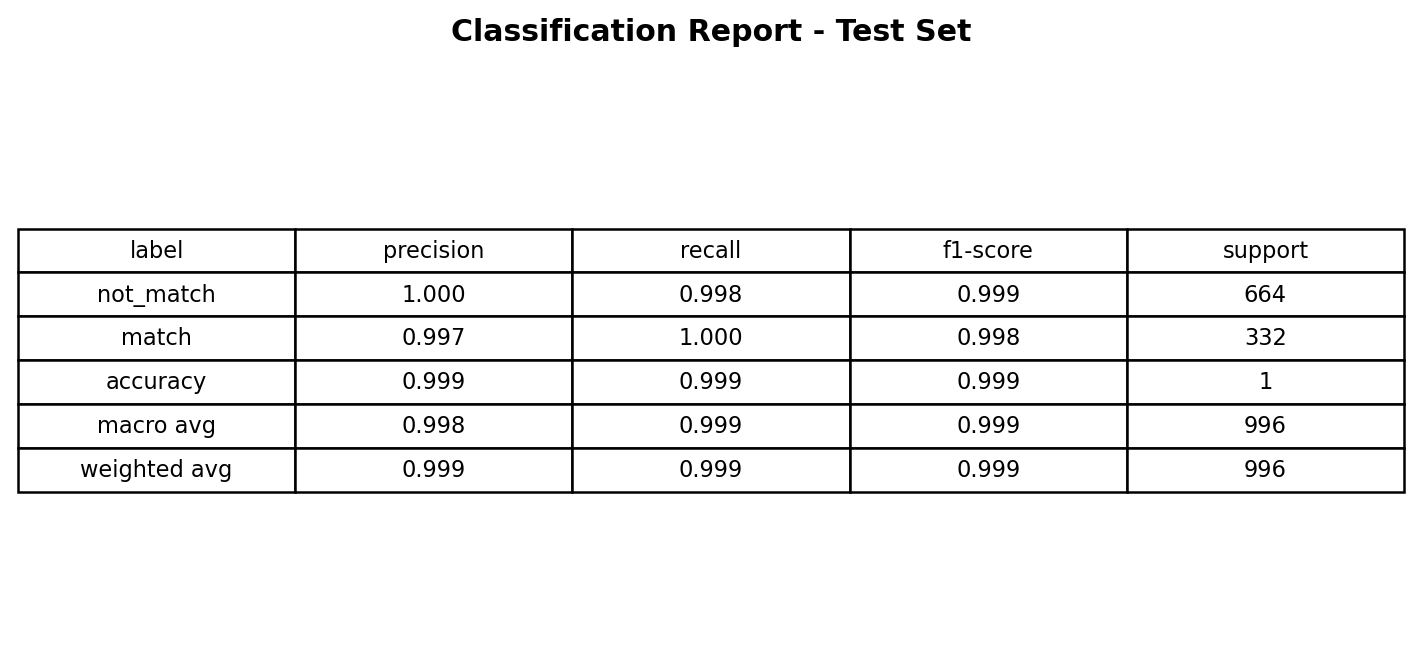

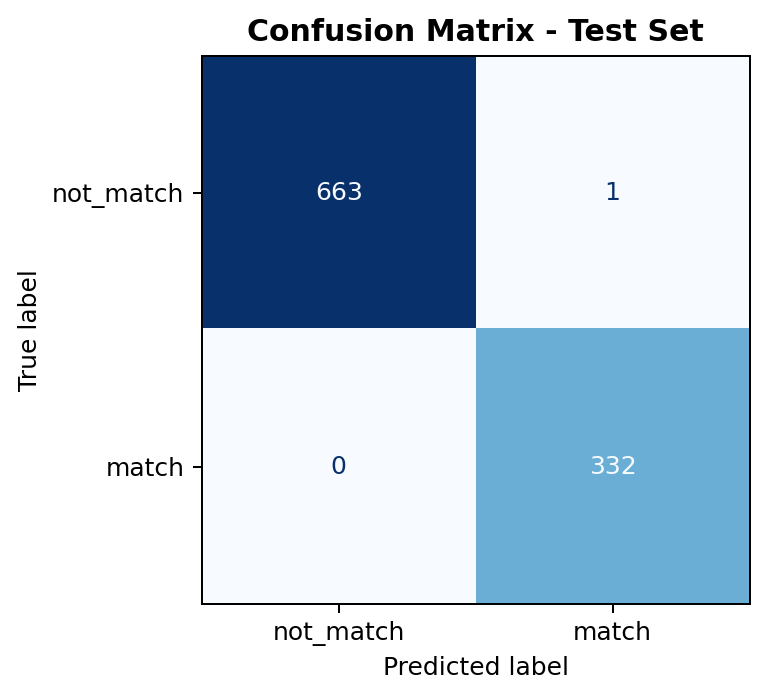

In [14]:
from IPython.display import Image as IPImage, display as ipy_display

classification_report_path = MODEL_DIR / 'classification_report.csv'
classification_report_image = MODEL_DIR / 'classification_report.png'
confusion_matrix_image = MODEL_DIR / 'confusion_matrix.png'

if classification_report_path.exists():
    report_df = pd.read_csv(classification_report_path)
    display(report_df.round(4))
else:
    print('classification_report.csv belum tersedia. Jalankan training terlebih dahulu.')

for image_path in [classification_report_image, confusion_matrix_image]:
    if image_path.exists():
        ipy_display(IPImage(filename=str(image_path)))
    else:
        print(f'{image_path.name} belum tersedia.')


In [15]:
history_path = MODEL_DIR / 'training_history.csv'
history_df = pd.read_csv(history_path)
epoch_log = history_df.copy()
epoch_log['epoch'] = epoch_log['epoch'].astype(int)
epoch_log['val_accuracy_target_met'] = epoch_log['val_binary_accuracy'] >= 0.85
epoch_log['val_mae_target_met'] = epoch_log['val_mae'] <= 0.02

if 'epoch_duration_seconds' in epoch_log.columns:
    epoch_log['epoch_duration_minutes'] = epoch_log['epoch_duration_seconds'] / 60

ordered_columns = [
    'epoch',
    'epoch_duration_seconds',
    'epoch_duration_minutes',
    'loss',
    'binary_accuracy',
    'mae',
    'val_loss',
    'val_binary_accuracy',
    'val_mae',
    'val_accuracy_target_met',
    'val_mae_target_met',
]
ordered_columns = [column for column in ordered_columns if column in epoch_log.columns]
display(epoch_log[ordered_columns].round(5))

if 'epoch_duration_seconds' in history_df.columns:
    total_seconds = history_df['epoch_duration_seconds'].sum()
    mean_seconds = history_df['epoch_duration_seconds'].mean()
    print(f'Total waktu epoch training: {total_seconds:.2f} detik ({total_seconds / 60:.2f} menit)')
    print(f'Rata-rata waktu per epoch: {mean_seconds:.2f} detik')

try:
    figure_count = 3 if 'epoch_duration_seconds' in history_df.columns else 2
    fig, axes = plt.subplots(1, figure_count, figsize=(7 * figure_count, 4))
    if figure_count == 1:
        axes = [axes]

    history_df.plot(x='epoch', y=['binary_accuracy', 'val_binary_accuracy'], marker='o', ax=axes[0])
    axes[0].axhline(0.85, color='#dc2626', linestyle='--', label='target accuracy')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_ylim(0.8, 1.01)
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    history_df.plot(x='epoch', y=['mae', 'val_mae'], marker='o', ax=axes[1])
    axes[1].axhline(0.02, color='#dc2626', linestyle='--', label='target MAE')
    axes[1].set_title('MAE per Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    if 'epoch_duration_seconds' in history_df.columns:
        history_df.plot(x='epoch', y='epoch_duration_seconds', kind='bar', color='#0f766e', ax=axes[2], legend=False)
        axes[2].set_title('Training Time per Epoch')
        axes[2].set_ylabel('Seconds')
        axes[2].set_xlabel('Epoch')
        for container in axes[2].containers:
            axes[2].bar_label(container, fmt='%.1fs', padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Plot dilewati:', exc)


,epoch,epoch_duration_seconds,epoch_duration_minutes,loss,binary_accuracy,mae,val_loss,val_binary_accuracy,val_mae,val_accuracy_target_met,val_mae_target_met
0,1,9.74492,0.16242,0.01847,0.98080,0.06818,0.08757,0.99699,0.33545,True,False
1,2,9.52208,0.15870,0.00434,0.99720,0.02389,0.03449,0.99598,0.22279,True,False
2,3,9.39219,0.15654,0.00418,0.99741,0.01652,0.01368,0.99900,0.13127,True,False
3,4,9.41069,0.15684,0.00474,0.99612,0.01573,0.00644,0.99900,0.07478,True,False
4,5,9.44473,0.15741,0.00357,0.99676,0.01507,0.00595,0.99598,0.02712,True,False
5,6,10.50512,0.17509,0.00411,0.99720,0.01333,0.00271,0.99699,0.01278,True,True


Total waktu epoch training: 58.02 detik (0.97 menit)
Rata-rata waktu per epoch: 9.67 detik


C:\Users\Admin\AppData\Local\Temp\ipykernel_14004\1082833978.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Exported Artifacts

In [16]:
artifact_rows = []
for path in [
    MODEL_DIR / 'career_match_model.keras',
    MODEL_DIR / 'saved_model',
    MODEL_DIR / 'jobs_catalog.json',
    MODEL_DIR / 'metrics.json',
    MODEL_DIR / 'tensorboard',
]:
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
    elif path.is_dir():
        size_mb = sum(item.stat().st_size for item in path.rglob('*') if item.is_file()) / (1024 * 1024)
    else:
        size_mb = 0
    artifact_rows.append({'artifact': str(path.relative_to(AIENGINE_ROOT)), 'exists': path.exists(), 'size_mb': round(size_mb, 3)})

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

ax = artifact_df.set_index('artifact')['size_mb'].plot(kind='barh', color='#9333ea')
ax.set_title('Exported Artifact Size')
ax.set_xlabel('Size (MB)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

,artifact,exists,size_mb
0,models\registry\career-match\v1\career_match_m...,True,3.464
1,models\registry\career-match\v1\saved_model,True,6.797
2,models\registry\career-match\v1\jobs_catalog.json,True,5.582
3,models\registry\career-match\v1\metrics.json,True,0.001
4,models\registry\career-match\v1\tensorboard,True,0.003


C:\Users\Admin\AppData\Local\Temp\ipykernel_14004\1829148494.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Inference Demo

In [17]:

importlib.invalidate_caches()
inference_module = importlib.import_module('career_match.inference')
inference_module = importlib.reload(inference_module)
CareerMatchService = inference_module.CareerMatchService

service = CareerMatchService(MODEL_DIR)
prediction = service.predict(
    skills=['Python', 'SQL', 'Machine Learning', 'Data Analysis', 'TensorFlow'],
    experience_years=2,
    education_level='bachelor',
    certifications=['TensorFlow Developer'],
    preferred_location='Jakarta',
    top_k=5,
)
prediction


{'predicted_role': 'Tenaga Pengajar It',
 'target_role': None,
 'role_family': 'design-content',
 'readiness_score': 79.21,
 'readiness_status': 'Cukup Siap',
 'match_confidence': 0.7921,
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'top_matches': [{'job_id': 'glints-1776679414-790',
   'job_title': 'Tenaga Pengajar It',
   'company': 'Digikidz',
   'location': 'Kab. Tangerang, Banten',
   'job_detail': 'https://glints.com/id/en/opportunities/jobs/tenaga-pengajar-it/a308572e-c7e6-4e49-837f-24ee55a60d5c?utm_referrer=explore&traceInfo=17cddaadb4bac2102035b5df6f5fb67e',
   'role_family': 'design-content',
   'work_mode': 'unknown',
   'required_experience_years': 1.0,
   'required_education': 'diploma',
   'match_score': 0.7921,
   'readiness_percentage': 79.21,
   'target_alignment': 0,
   'matched_skills': ['machine learning', 'python'],
   'missing_skills

In [18]:
top_matches_df = pd.DataFrame(prediction['top_matches'])
display(top_matches_df)

plot_df = top_matches_df.sort_values('readiness_percentage')
colors = ['#16a34a' if value >= 85 else '#f59e0b' if value >= 70 else '#dc2626' for value in plot_df['readiness_percentage']]
ax = plot_df.plot(kind='barh', x='job_title', y='readiness_percentage', legend=False, color=colors, figsize=(10, 5))
ax.set_title('Top Match Readiness Score')
ax.set_xlabel('Readiness (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print('Predicted role:', prediction['predicted_role'])
print('Readiness score:', prediction['readiness_score'])
print('Skill gap:', prediction['skill_gap'])
print('Recommendations:')
for item in prediction['recommendations']:
    print('-', item)

,job_id,job_title,company,location,job_detail,role_family,work_mode,required_experience_years,required_education,match_score,readiness_percentage,target_alignment,matched_skills,missing_skills
0,glints-1776679414-790,Tenaga Pengajar It,Digikidz,"Kab. Tangerang, Banten",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7921,79.21,0,"[machine learning, python]",[pytorch]
1,glints-1778509661-793,Tenaga Pengajar It,Digikidz,"Kab. Tangerang, Banten",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7825,78.25,0,"[python, machine learning]",[pytorch]
2,glints-1778509687-802,Tenaga Pengajar It,Digikidz,"Medan, Sumatera Utara",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7825,78.25,0,"[python, machine learning]",[pytorch]
3,linkedin-linkedin-2013,Data Engineer,Vlink Inc,"Jakarta, Indonesia",,data-ai,unknown,0.0,bachelor,0.3667,36.67,0,"[python, sql]",[etl]
4,glints-1776678050-440,Data Pipeline,Xnine Indonesia,"Jakarta Selatan, Dki Jakarta",https://glints.com/id/en/opportunities/jobs/da...,data-ai,onsite,1.0,bachelor,0.3600,36.00,0,"[sql, data analysis]","[elasticsearch, grafana, agile]"


Predicted role: Tenaga Pengajar It
Readiness score: 79.21
Skill gap: ['pytorch']
Recommendations:
- Bangun bukti portofolio untuk pytorch lewat mini project, latihan studi kasus, dan sertifikasi dasar.


C:\Users\Admin\AppData\Local\Temp\ipykernel_14004\500733370.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. REST API Contract

FastAPI service dapat dijalankan dari folder `AIEngine`:

```bash
uvicorn career_match.app:app --app-dir services/career-match/src --host 127.0.0.1 --port 8001
```

Endpoint utama:

- `GET /health`
- `POST /predict`

Kontrak lengkap tersedia di `AIEngine/shared/schemas/career_match_contract.json`.

In [19]:
contract_path = AIENGINE_ROOT / 'shared' / 'schemas' / 'career_match_contract.json'
contract = json.loads(contract_path.read_text(encoding='utf-8'))
contract

{'service': 'career-match',
 'version': '1.2.0',
 'endpoints': {'predict': 'POST /predict', 'predict_web': 'POST /predict/web'},
 'request': {'skills': {'type': 'array<string>|string',
   'required': True,
   'description': 'Daftar skill kandidat. Untuk /predict disarankan array; /predict/web boleh string dipisah koma.'},
  'experience_years': {'type': 'number',
   'required': 'true for /predict, optional for /predict/web',
   'min': 0,
   'max': 60},
  'education_level': {'type': 'string|integer',
   'required': False,
   'examples': ['sma', 'd3', 's1', 'diploma', 'bachelor', 'master', 3]},
  'certifications': {'type': 'array<string>|string',
   'required': 'true for /predict, optional for /predict/web',
   'description': 'Daftar sertifikasi kandidat. Kirim array kosong jika kandidat belum memiliki sertifikasi.'},
  'interests': {'type': 'array<string>|string|null',
   'required': False,
   'description': 'Minat dan bakat dari form web.'},
  'experience_text': {'type': 'string|null',


## 10. TensorBoard

TensorBoard event files menyimpan metrik training per epoch. Jika training dijalankan berkali-kali, TensorBoard akan membuat beberapa file event. Itu normal. Untuk final demo, cukup gunakan log terakhir atau kosongkan folder TensorBoard sebelum retraining final.

Jalankan dari folder `AIEngine`:

```bash
tensorboard --logdir models/registry/career-match/v1/tensorboard
```

In [20]:
event_files = []
for path in (MODEL_DIR / 'tensorboard').rglob('events.out.tfevents*'):
    event_files.append(
        {
            'run': path.parent.name,
            'file': path.name,
            'size_kb': round(path.stat().st_size / 1024, 2),
            'last_modified': path.stat().st_mtime,
        }
    )

event_df = pd.DataFrame(event_files).sort_values(['run', 'file'])
display(event_df)

if not event_df.empty:
    summary_df = event_df.groupby('run').agg(file_count=('file', 'count'), total_size_kb=('size_kb', 'sum'))
    display(summary_df)
    ax = summary_df['file_count'].plot(kind='bar', color='#2563eb')
    ax.set_title('TensorBoard Event Files by Run')
    ax.set_xlabel('Run')
    ax.set_ylabel('Event File Count')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

,run,file,size_kb,last_modified
0,train,events.out.tfevents.1778658055.ASUS-TUF-A15.46...,1.69,1.778658e+09
1,validation,events.out.tfevents.1778658055.ASUS-TUF-A15.46...,1.29,1.778658e+09


,file_count,total_size_kb
run,,
train,1,1.69
validation,1,1.29


C:\Users\Admin\AppData\Local\Temp\ipykernel_14004\1542584561.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
